# Day 4 — Delivery Time Prediction

## Objective

Build supervised regression models to predict actual delivery time using order, delivery, restaurant, and time-based features.

## Models

- Baseline Linear Regression
- Random Forest Regressor
- Ridge Regression
- Lasso Regression

## Evaluation Metrics

- MAE
- RMSE
- R²

In [53]:
# Import numerical and data manipulation libraries

import numpy as np
import pandas as pd


# Import plotting library

import matplotlib.pyplot as plt


# Import train-test split and cross-validation

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)


# Import preprocessing tools

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)


# Import regression models

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import RandomForestRegressor


# Import evaluation metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [54]:
# Load the processed datasets required for delivery prediction

customers1 = pd.read_csv('../data/processed/customers_clean.csv')

restaurants1 = pd.read_csv('../data/processed/restaurants_clean.csv')

orders1 = pd.read_csv('../data/processed/orders_clean.csv')

deliveries1 = pd.read_csv('../data/processed/deliveries_clean.csv')

# Make a copy of the datasets

customers = customers1.copy()

restaurants = restaurants1.copy()

orders = orders1.copy()

deliveries = deliveries1.copy()


In [55]:
# Display dataset sizes

print('Customers:', customers.shape)
print('Restaurants:', restaurants.shape)
print('Orders:', orders.shape)
print('Deliveries:', deliveries.shape)

Customers: (1500, 6)
Restaurants: (200, 7)
Orders: (10000, 11)
Deliveries: (9188, 7)


## Building the Modeling Dataset

The modeling dataset combines order, delivery, and restaurant information.

The target variable is `actual_delivery_time_min`.

Identifiers such as `order_id` and `restaurant_id` are used only to join the datasets and will be removed before model training.

In [56]:
# Create a copy of the orders dataset

delivery_model = orders.copy()


# Add delivery information

delivery_model = delivery_model.merge(
    deliveries[
        [
            'order_id',
            'delivery_distance_km',
            'preparation_time_min',
            'actual_delivery_time_min'
        ]
    ],
    on='order_id',
    how='inner'
)


# Add restaurant information

delivery_model = delivery_model.merge(
    restaurants[
        [
            'restaurant_id',
            'restaurant_rating',
            'restaurant_category'
        ]
    ],
    on='restaurant_id',
    how='left'
)

In [57]:
# Convert order timestamp to datetime

delivery_model['order_timestamp'] = pd.to_datetime(
    delivery_model['order_timestamp']
)


# Extract the hour of the order

delivery_model['order_hour'] = (
    delivery_model['order_timestamp'].dt.hour
)


# Extract the day of the week

delivery_model['day_of_week'] = (
    delivery_model['order_timestamp'].dt.dayofweek
)


# Create a weekend indicator

delivery_model['is_weekend'] = (
    delivery_model['day_of_week'] >= 5
).astype(int)

In [58]:
# Display the shape of the modeling dataset

print('Shape:', delivery_model.shape)


# Display the columns

print('\nColumns:')

print(
    delivery_model.columns.tolist()
)


# Display the first five rows

delivery_model.head()

Shape: (9188, 19)

Columns:
['order_id', 'customer_id', 'restaurant_id', 'order_timestamp', 'order_status', 'order_amount', 'tip_amount', 'items_count', 'payment_method', 'weather', 'traffic_condition', 'delivery_distance_km', 'preparation_time_min', 'actual_delivery_time_min', 'restaurant_rating', 'restaurant_category', 'order_hour', 'day_of_week', 'is_weekend']


,order_id,customer_id,restaurant_id,order_timestamp,order_status,order_amount,tip_amount,items_count,payment_method,weather,traffic_condition,delivery_distance_km,preparation_time_min,actual_delivery_time_min,restaurant_rating,restaurant_category,order_hour,day_of_week,is_weekend
0,ORD_000001,CUST_01488,REST_0096,2025-02-16 18:06:14,Delivered,423.90,23.33,2,UPI,Rain,Medium,4.26,16.7,43.0,3.2,Mid-range,18,6,1
1,ORD_000002,CUST_00137,REST_0120,2025-04-04 11:23:54,Delivered,82.53,9.30,1,UPI,Clear,High,0.91,20.6,23.6,4.0,Budget,11,4,0
2,ORD_000003,CUST_00193,REST_0142,2025-06-02 18:35:49,Delivered,544.40,81.65,6,Credit Card,Rain,Medium,10.60,19.5,68.2,4.2,Budget,18,0,0
3,ORD_000004,CUST_01240,REST_0154,2025-05-22 12:52:49,Delivered,1873.11,93.99,4,Wallet,Clear,Low,7.79,26.6,53.1,3.6,Premium,12,3,0
4,ORD_000005,CUST_01300,REST_0170,2025-02-05 12:33:20,Delivered,1137.79,249.06,5,Debit Card,Clear,Medium,6.73,18.3,43.0,4.2,Mid-range,12,2,0


## Target Variable — Delivery Time

Before building regression models, we need to understand the distribution of the target variable.

We will examine its central tendency, spread, minimum and maximum values, and potential outliers.

In [59]:
# Display descriptive statistics for delivery time

delivery_model['actual_delivery_time_min'].describe()

count    9188.000000
mean       50.146104
std        20.796136
min         8.000000
25%        35.600000
50%        46.600000
75%        60.700000
max       150.000000
Name: actual_delivery_time_min, dtype: float64

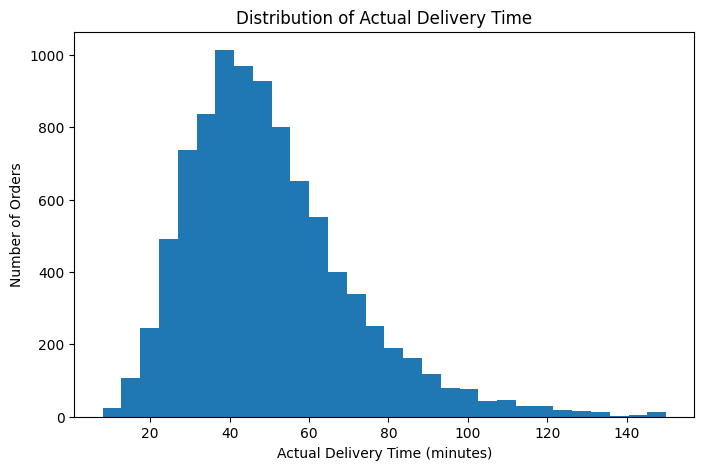

In [60]:
# Plot the distribution of actual delivery time

plt.figure(figsize=(8, 5))

plt.hist(
    delivery_model['actual_delivery_time_min'],
    bins=30
)

plt.xlabel('Actual Delivery Time (minutes)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Actual Delivery Time')

plt.show()

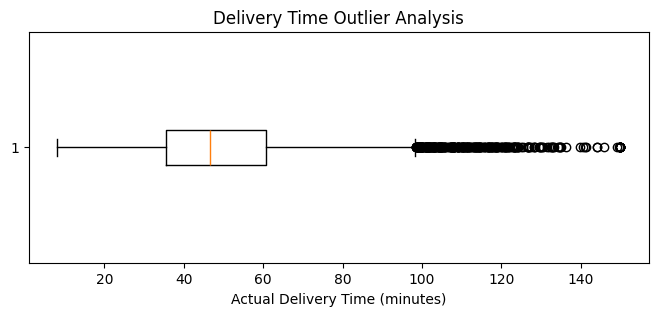

In [61]:
# Plot a box plot to identify potential outliers

plt.figure(figsize=(8, 3))

plt.boxplot(
    delivery_model['actual_delivery_time_min'],
    vert=False
)

plt.xlabel('Actual Delivery Time (minutes)')
plt.title('Delivery Time Outlier Analysis')

plt.show()

In [62]:
# Calculate the first and third quartiles

Q1 = delivery_model['actual_delivery_time_min'].quantile(0.25)
Q3 = delivery_model['actual_delivery_time_min'].quantile(0.75)


# Calculate the interquartile range

IQR = Q3 - Q1


# Calculate outlier boundaries

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


# Count potential outliers

outliers = delivery_model[
    (
        delivery_model['actual_delivery_time_min'] < lower_bound
    )
    |
    (
        delivery_model['actual_delivery_time_min'] > upper_bound
    )
]


print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower bound:', lower_bound)
print('Upper bound:', upper_bound)
print('Number of potential outliers:', len(outliers))

Q1: 35.6
Q3: 60.7
IQR: 25.1
Lower bound: -2.0500000000000043
Upper bound: 98.35000000000001
Number of potential outliers: 289


## Target Outlier Analysis

The IQR method identified an upper outlier boundary of approximately 98.35 minutes.

There are 289 potential outliers above this threshold. These observations will not be removed automatically because unusually long deliveries may represent genuine operational conditions rather than data errors.

The negative lower bound is not practically meaningful because delivery time cannot be negative.

Therefore, the potential outliers will be retained for modeling and evaluated using regression metrics that are sensitive to prediction errors.

## Feature Relationships

Correlation measures the strength and direction of a linear relationship between numerical variables.

A value close to +1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship.

We will examine correlations between numerical features and delivery time to identify potentially useful predictors.

In [63]:
# Select numerical columns

numeric_columns = delivery_model.select_dtypes(
    include=np.number
).columns


# Calculate correlations with delivery time

delivery_correlations = (
    delivery_model[numeric_columns]
    .corr()['actual_delivery_time_min']
    .sort_values(ascending=False)
)


# Display correlations

delivery_correlations

actual_delivery_time_min    1.000000
delivery_distance_km        0.843276
preparation_time_min        0.327670
order_amount                0.016254
items_count                 0.007880
is_weekend                  0.003201
order_hour                 -0.003478
restaurant_rating          -0.004919
day_of_week                -0.012657
tip_amount                 -0.024582
Name: actual_delivery_time_min, dtype: float64

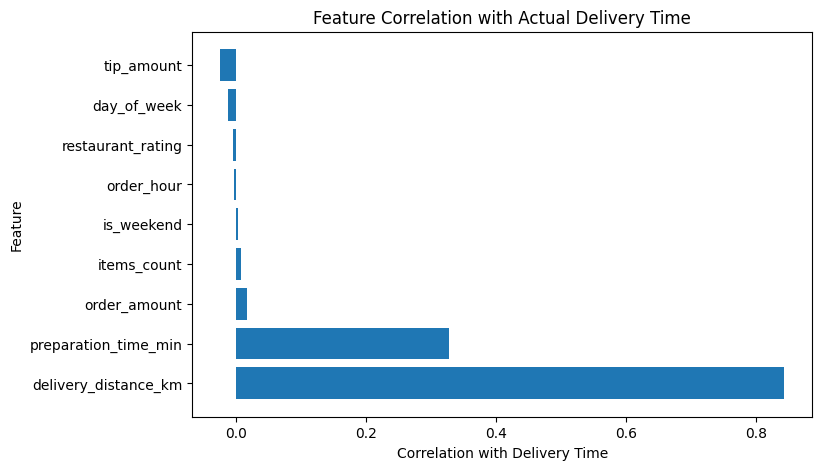

In [64]:
# Remove the target itself from the correlation results

feature_correlations = delivery_correlations.drop(
    'actual_delivery_time_min'
)


# Plot correlations

plt.figure(figsize=(8, 5))

plt.barh(
    feature_correlations.index,
    feature_correlations.values
)

plt.xlabel('Correlation with Delivery Time')
plt.ylabel('Feature')
plt.title('Feature Correlation with Actual Delivery Time')

plt.show()

## Relationship Between Key Features and Delivery Time

Delivery distance and preparation time show the strongest numerical relationships with delivery time.

Scatter plots are used to visually examine whether these relationships are consistent and whether unusual observations are present.

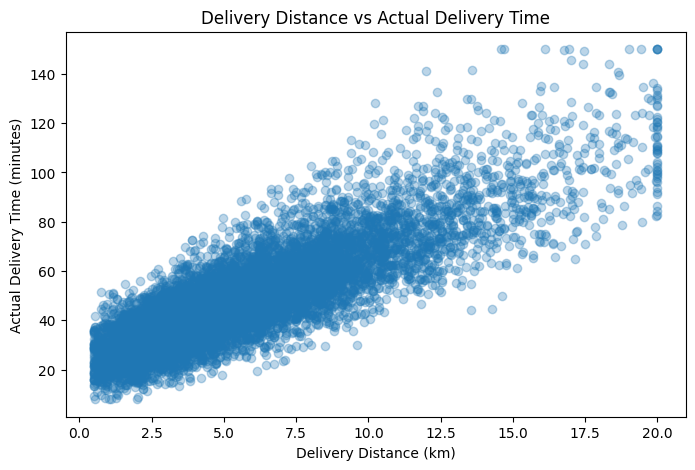

In [65]:
# Plot delivery distance against delivery time

plt.figure(figsize=(8, 5))

plt.scatter(
    delivery_model['delivery_distance_km'],
    delivery_model['actual_delivery_time_min'],
    alpha=0.3
)

plt.xlabel('Delivery Distance (km)')
plt.ylabel('Actual Delivery Time (minutes)')
plt.title('Delivery Distance vs Actual Delivery Time')

plt.show()

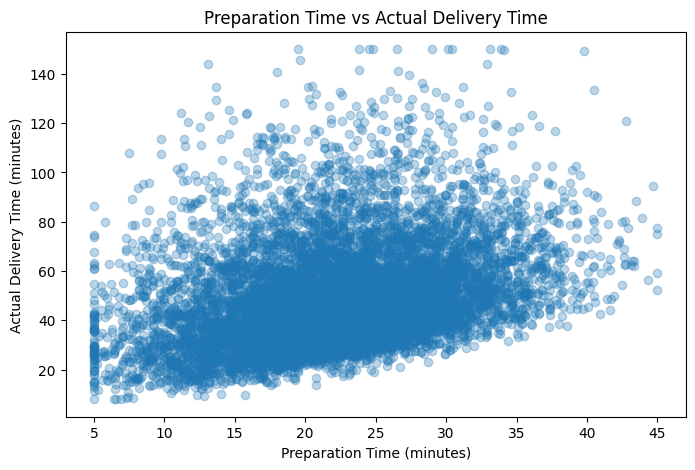

In [66]:
# Plot preparation time against delivery time

plt.figure(figsize=(8, 5))

plt.scatter(
    delivery_model['preparation_time_min'],
    delivery_model['actual_delivery_time_min'],
    alpha=0.3
)

plt.xlabel('Preparation Time (minutes)')
plt.ylabel('Actual Delivery Time (minutes)')
plt.title('Preparation Time vs Actual Delivery Time')

plt.show()

### EDA Conclusion

Delivery distance has the strongest linear relationship with actual delivery time, followed by preparation time.

The scatter plots show that longer delivery distances generally correspond to longer delivery times. Preparation time also contributes to delivery duration, although the relationship is weaker.

The remaining numerical features show relatively weak linear relationships and may still provide predictive value when combined with other features or modeled using non-linear algorithms.

## Feature Selection

The selected features represent operational, order, restaurant, and time-related factors that may influence delivery time.

Identifiers such as `order_id` and `restaurant_id` are removed because they identify individual records rather than represent meaningful predictive information.

The original timestamp is also removed after extracting useful time-based features such as order hour, day of week, and weekend status.

In [67]:
# Define the target variable

target = 'actual_delivery_time_min'


# Define the numerical features

numerical_features = [
    'delivery_distance_km',
    'preparation_time_min',
    'order_amount',
    'items_count',
    'tip_amount',
    'order_hour',
    'day_of_week',
    'is_weekend',
    'restaurant_rating'
]


# Define the categorical features that actually exist
# in the modeling dataset

categorical_features = [
    'traffic_condition',
    'restaurant_category'
]


# Combine all selected features

selected_features = (
    numerical_features +
    categorical_features
)


# Create the modeling feature dataset

X = delivery_model[selected_features].copy()


# Create the target variable

y = delivery_model[target].copy()


# Display selected features

print('Features:')
print(X.columns.tolist())


# Display target

print('\nTarget:')
print(y.name)

Features:
['delivery_distance_km', 'preparation_time_min', 'order_amount', 'items_count', 'tip_amount', 'order_hour', 'day_of_week', 'is_weekend', 'restaurant_rating', 'traffic_condition', 'restaurant_category']

Target:
actual_delivery_time_min


In [68]:
# Check for missing values in the selected features

print('Missing values in features:')
print(X.isnull().sum())


# Check for missing values in the target

print('\nMissing values in target:')
print(y.isnull().sum())

Missing values in features:
delivery_distance_km    0
preparation_time_min    0
order_amount            0
items_count             0
tip_amount              0
order_hour              0
day_of_week             0
is_weekend              0
restaurant_rating       0
traffic_condition       0
restaurant_category     0
dtype: int64

Missing values in target:
0


## Data Quality Check

The selected modeling features and target variable contain no missing values. Therefore, no missing-value imputation is required before model training.

## Train-Test Split

The dataset is divided into training and testing sets.

The training data is used to learn patterns, while the test data is kept separate to evaluate how well the trained models generalize to unseen observations.

A 20% test split is used.

In [69]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# Display the resulting shapes

print('Training features:', X_train.shape)
print('Testing features:', X_test.shape)

print('Training target:', y_train.shape)
print('Testing target:', y_test.shape)

Training features: (7350, 11)
Testing features: (1838, 11)
Training target: (7350,)
Testing target: (1838,)


## Categorical Feature Encoding

Machine learning regression models require numerical inputs.

The categorical features `traffic_condition` and `restaurant_category` are converted into binary indicator columns using one-hot encoding.

This allows the models to use categorical information without assigning an artificial numerical order to the categories.


In [71]:
# Convert categorical variables into one-hot encoded columns

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
)


# Make sure both datasets have exactly the same columns

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)


# Display the resulting columns

print(X_train_encoded.columns.tolist())

['delivery_distance_km', 'preparation_time_min', 'order_amount', 'items_count', 'tip_amount', 'order_hour', 'day_of_week', 'is_weekend', 'restaurant_rating', 'traffic_condition_Low', 'traffic_condition_Medium', 'traffic_condition_Severe', 'restaurant_category_Mid-range', 'restaurant_category_Premium']


In [72]:
# Display the data types after encoding

print(X_train_encoded.dtypes)

delivery_distance_km             float64
preparation_time_min             float64
order_amount                     float64
items_count                        int64
tip_amount                       float64
order_hour                         int32
day_of_week                        int32
is_weekend                         int64
restaurant_rating                float64
traffic_condition_Low               bool
traffic_condition_Medium            bool
traffic_condition_Severe            bool
restaurant_category_Mid-range       bool
restaurant_category_Premium         bool
dtype: object


## Feature Standardization

Standardization transforms numerical features so that they have a mean of approximately 0 and a standard deviation of approximately 1.

This is particularly important for Ridge and Lasso because regularization penalizes model coefficients. Without scaling, features with larger numerical ranges could have an disproportionate influence on the penalty.

The scaler is fitted only on the training data to avoid data leakage.

In [73]:
# Create the StandardScaler

scaler = StandardScaler()


# Fit the scaler only on the training data

X_train_scaled = scaler.fit_transform(
    X_train_encoded
)


# Transform the test data using the same scaler

X_test_scaled = scaler.transform(
    X_test_encoded
)

In [74]:
# Create the Linear Regression model

linear_model = LinearRegression()


# Train the model

linear_model.fit(
    X_train_scaled,
    y_train
)


# Generate predictions

linear_predictions = linear_model.predict(
    X_test_scaled
)

In [75]:
# Calculate Mean Absolute Error

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)


# Calculate Root Mean Squared Error

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)


# Calculate R-squared

linear_r2 = r2_score(
    y_test,
    linear_predictions
)


# Display the results

print('Linear Regression MAE:', round(linear_mae, 2))
print('Linear Regression RMSE:', round(linear_rmse, 2))
print('Linear Regression R²:', round(linear_r2, 4))

Linear Regression MAE: 5.23
Linear Regression RMSE: 7.03
Linear Regression R²: 0.8786


### Actual vs Predicted Delivery Time — Linear Regression

This plot compares actual delivery times against the values predicted
by the linear regression model. Each point represents one delivery in
the test set. The red dashed line represents perfect prediction, where
the predicted value equals the actual value.

Points that fall close to this line indicate accurate predictions,
while points further away indicate larger prediction errors. This
visualization complements the MAE, RMSE, and R² metrics by showing
how errors are distributed across the range of delivery times, rather
than summarizing them into a single number.

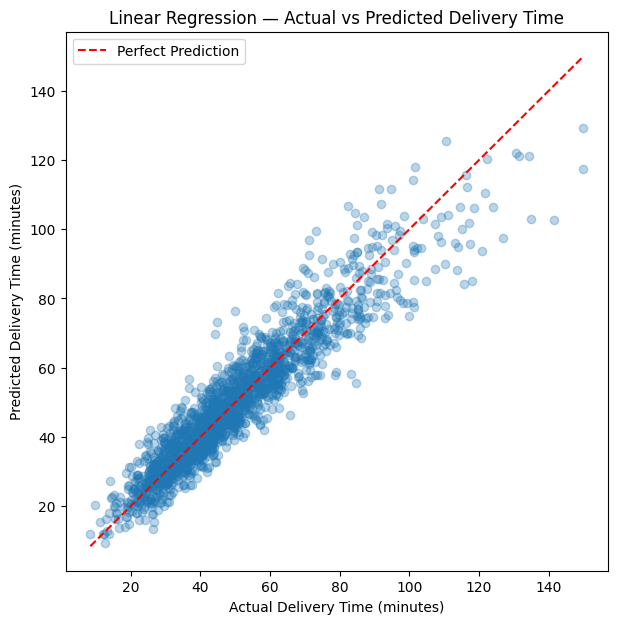

In [83]:
# Plot actual delivery time (x-axis) vs predicted delivery time (y-axis)

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.3
)

# Add a diagonal reference line representing perfect prediction

min_val = min(y_test.min(), linear_predictions.min())
max_val = max(y_test.max(), linear_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel('Actual Delivery Time (minutes)')
plt.ylabel('Predicted Delivery Time (minutes)')
plt.title('Linear Regression — Actual vs Predicted Delivery Time')
plt.legend()

plt.show()

### Random Forest Regressor

Random Forest is an ensemble model that builds many decision trees on
different random subsets of the training data and features, then
averages their predictions. This allows it to capture non-linear
relationships and interactions between features, which a linear model
cannot represent.

Random Forest does not require feature scaling, so it is trained on
the encoded (but unscaled) feature set.

In [84]:
# Create the Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Train the model

rf_model.fit(
    X_train_encoded,
    y_train
)

# Generate predictions on the test set

rf_predictions = rf_model.predict(
    X_test_encoded
)

In [85]:
# Calculate Mean Absolute Error

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

# Calculate Root Mean Squared Error

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

# Calculate R-squared

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

# Display the results

print('Random Forest MAE:', round(rf_mae, 2))
print('Random Forest RMSE:', round(rf_rmse, 2))
print('Random Forest R²:', round(rf_r2, 4))

Random Forest MAE: 5.07
Random Forest RMSE: 6.87
Random Forest R²: 0.8843


### Actual vs Predicted Delivery Time — Random Forest

This plot follows the same format as the linear regression plot,
comparing actual delivery times to the values predicted by the
Random Forest model. Comparing the spread of points around the
red diagonal line across both models gives a visual sense of which
model fits the data better, in addition to the MAE, RMSE, and R²
values already calculated.

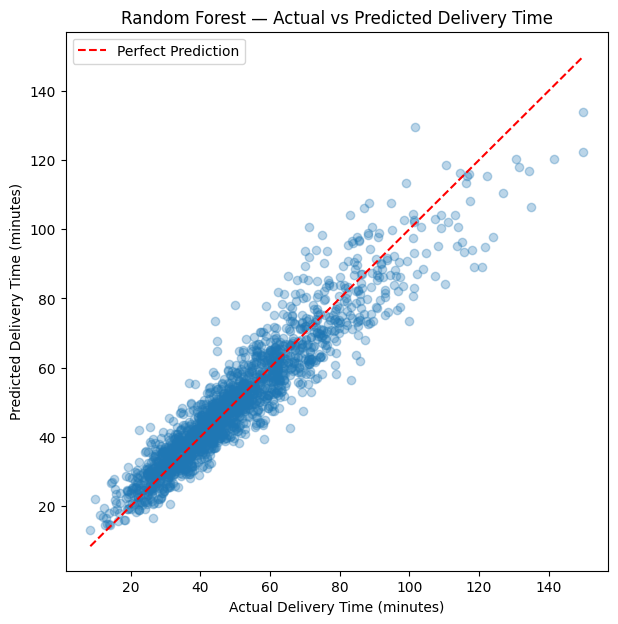

In [86]:
# Plot actual delivery time (x-axis) vs predicted delivery time (y-axis)

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.3
)

# Add a diagonal reference line representing perfect prediction

min_val = min(y_test.min(), rf_predictions.min())
max_val = max(y_test.max(), rf_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel('Actual Delivery Time (minutes)')
plt.ylabel('Predicted Delivery Time (minutes)')
plt.title('Random Forest — Actual vs Predicted Delivery Time')
plt.legend()

plt.show()

### Checking for Overfitting

A model that overfits performs very well on the data it was trained
on but poorly on unseen data. To check for this, we compare the
Random Forest's R² on the training set against its R² on the test
set. A large gap between the two would indicate the model has
memorized patterns specific to the training data rather than learning
patterns that generalize.

In [87]:
# Generate predictions on the training set

rf_train_predictions = rf_model.predict(
    X_train_encoded
)

# Calculate R-squared on the training set

rf_train_r2 = r2_score(
    y_train,
    rf_train_predictions
)

# Display training vs test R-squared

print('Random Forest Training R²:', round(rf_train_r2, 4))
print('Random Forest Test R²:', round(rf_r2, 4))

Random Forest Training R²: 0.9371
Random Forest Test R²: 0.8843


### Feature Importance

Random Forest provides an importance score for each feature, based on
how much it reduces prediction error across all trees in the
ensemble. Higher values indicate the feature contributed more to the
model's predictions.

In [88]:
# Extract feature importances from the trained model

rf_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train_encoded.columns
).sort_values(ascending=False)

# Display feature importances

rf_importances

delivery_distance_km             0.775954
preparation_time_min             0.126851
traffic_condition_Severe         0.032743
traffic_condition_Low            0.023686
traffic_condition_Medium         0.020067
tip_amount                       0.004729
order_amount                     0.004554
order_hour                       0.003262
restaurant_rating                0.003249
day_of_week                      0.002044
items_count                      0.001660
restaurant_category_Mid-range    0.000855
is_weekend                       0.000210
restaurant_category_Premium      0.000134
dtype: float64

### Feature Importance Plot

The bar chart below visualizes the feature importance values from the
previous cell, making it easier to compare the relative contribution
of each feature to the model's predictions.

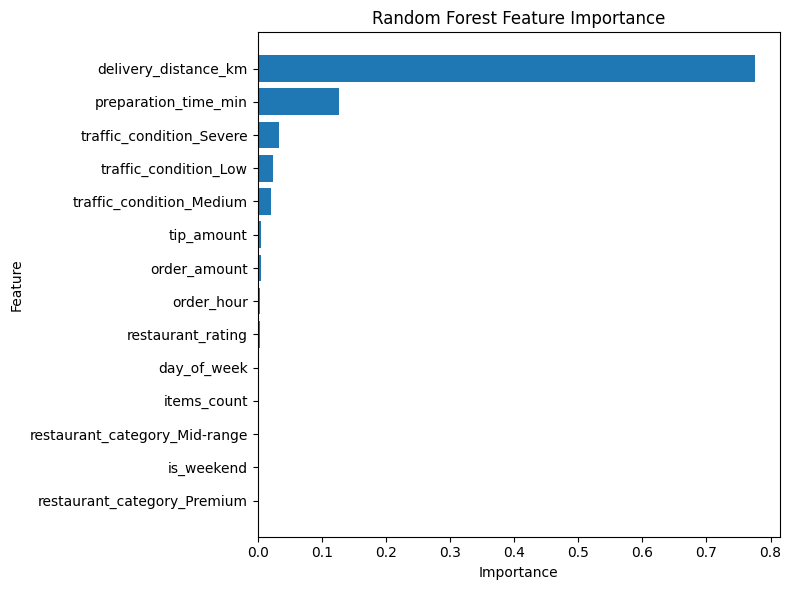

In [89]:
# Plot feature importances

plt.figure(figsize=(8, 6))

plt.barh(
    rf_importances.index[::-1],
    rf_importances.values[::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.tight_layout()
plt.show()

### Ridge and Lasso Regression

Ridge and Lasso are linear models that add a penalty on the size of
the coefficients. This penalty discourages the model from assigning
very large weights to any one feature, which helps control
overfitting and reduces the impact of correlated features.

Ridge shrinks coefficients toward zero but rarely sets them exactly
to zero. Lasso can shrink some coefficients exactly to zero, which
effectively removes those features from the model.

Both models are trained on the scaled features, since the penalty is
sensitive to the numerical range of each feature.

In [90]:
# Create the Ridge Regression model

ridge_model = Ridge(
    alpha=1.0,
    random_state=42
)

# Train the model

ridge_model.fit(
    X_train_scaled,
    y_train
)

# Generate predictions

ridge_predictions = ridge_model.predict(
    X_test_scaled
)

# Calculate evaluation metrics

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
ridge_r2 = r2_score(y_test, ridge_predictions)

# Display the results

print('Ridge Regression MAE:', round(ridge_mae, 2))
print('Ridge Regression RMSE:', round(ridge_rmse, 2))
print('Ridge Regression R²:', round(ridge_r2, 4))

Ridge Regression MAE: 5.23
Ridge Regression RMSE: 7.03
Ridge Regression R²: 0.8786


In [91]:
# Create the Lasso Regression model

lasso_model = Lasso(
    alpha=0.1,
    random_state=42
)

# Train the model

lasso_model.fit(
    X_train_scaled,
    y_train
)

# Generate predictions

lasso_predictions = lasso_model.predict(
    X_test_scaled
)

# Calculate evaluation metrics

lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_predictions))
lasso_r2 = r2_score(y_test, lasso_predictions)

# Display the results

print('Lasso Regression MAE:', round(lasso_mae, 2))
print('Lasso Regression RMSE:', round(lasso_rmse, 2))
print('Lasso Regression R²:', round(lasso_r2, 4))

Lasso Regression MAE: 5.21
Lasso Regression RMSE: 7.03
Lasso Regression R²: 0.8788


### Lasso Coefficients

Because Lasso can shrink coefficients exactly to zero, we can inspect
its coefficients to see which features it effectively removed from
the model. This gives an indication of which features Lasso
considered redundant or unimportant, given the other features
already in the model.

In [92]:
# Extract Lasso coefficients

lasso_coefficients = pd.Series(
    lasso_model.coef_,
    index=X_train_encoded.columns
).sort_values()

# Display coefficients

lasso_coefficients

# Count how many coefficients were shrunk to exactly zero

n_zero_coefficients = (lasso_coefficients == 0).sum()

print('Number of features with a coefficient of zero:', n_zero_coefficients)

Number of features with a coefficient of zero: 6


### Conclusion — Lasso Feature Selection

Lasso reduced 6 of the 14 features to a coefficient of exactly zero,
meaning it effectively excluded them from the model. This suggests
that, once features like delivery distance, preparation time, and
traffic condition are included, several of the remaining features
(e.g. restaurant category, day of week) add little additional
predictive value. This is consistent with the Random Forest feature
importance results, where the same features scored lowest.

### Cross-Validation

The train/test split gives one estimate of model performance, but
that estimate depends on which rows happened to land in the test set.
5-fold cross-validation splits the training data into 5 parts, trains
the model 5 times (each time holding out a different part for
validation), and averages the results. This gives a more reliable
estimate of how well each model generalizes.

Scikit-learn scores cross-validation using negative MAE by convention
(since it always tries to maximize a score), so the results are
negated back to positive for reporting.

In [93]:
# Run 5-fold cross-validation for each model

linear_cv_scores = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

rf_cv_scores = cross_val_score(
    RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    X_train_encoded,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

ridge_cv_scores = cross_val_score(
    Ridge(alpha=1.0, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

lasso_cv_scores = cross_val_score(
    Lasso(alpha=0.1, random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

# Display mean cross-validated MAE for each model

print('Linear Regression CV MAE:', round(-linear_cv_scores.mean(), 2), '+/-', round(linear_cv_scores.std(), 2))
print('Random Forest CV MAE:', round(-rf_cv_scores.mean(), 2), '+/-', round(rf_cv_scores.std(), 2))
print('Ridge Regression CV MAE:', round(-ridge_cv_scores.mean(), 2), '+/-', round(ridge_cv_scores.std(), 2))
print('Lasso Regression CV MAE:', round(-lasso_cv_scores.mean(), 2), '+/-', round(lasso_cv_scores.std(), 2))

Linear Regression CV MAE: 5.35 +/- 0.09
Random Forest CV MAE: 5.14 +/- 0.12
Ridge Regression CV MAE: 5.35 +/- 0.09
Lasso Regression CV MAE: 5.33 +/- 0.09


### Model Comparison

The table below summarizes test-set MAE, RMSE, and R² for all four
models, allowing a direct comparison of their performance.

In [94]:
# Build a comparison table of all models

model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MAE': [
        linear_mae,
        rf_mae,
        ridge_mae,
        lasso_mae
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse,
        ridge_rmse,
        lasso_rmse
    ],
    'R2': [
        linear_r2,
        rf_r2,
        ridge_r2,
        lasso_r2
    ]
}).sort_values('MAE').reset_index(drop=True)

# Display the comparison table

model_comparison

,Model,MAE,RMSE,R2
0,Random Forest,5.071926,6.868536,0.884260
1,Lasso Regression,5.205600,7.027361,0.878846
2,Ridge Regression,5.231976,7.033644,0.878629
3,Linear Regression,5.232129,7.033675,0.878628


### Final Model Selection

Random Forest achieved the lowest MAE (5.07 minutes) and RMSE (6.87
minutes) and the highest R² (0.884) on the test set, and it also had
the lowest cross-validated MAE (5.14). This makes it the best
performing model among the four tested.

Linear Regression, Ridge, and Lasso all performed very similarly to
each other, indicating that the relationship between the features and
delivery time is close to linear, and that regularization did not
meaningfully change performance for this dataset. Random Forest's
improvement over these three suggests it is capturing some
non-linear or interaction effects that the linear models cannot,
though the gap is modest.

Feature importance results from Random Forest showed that delivery
distance and preparation time are by far the strongest predictors of
delivery time, together accounting for over 90% of the model's total
importance.

### Business Interpretation

Delivery distance is by far the strongest driver of delivery time,
followed by preparation time. Traffic condition also plays a role,
while order-level and restaurant-level features (order amount, items
count, restaurant rating, restaurant category) contribute very
little.

This suggests that delivery time is primarily an operational and
logistical outcome rather than something driven by order
characteristics or restaurant quality. Two practical implications
follow:

1. Delivery-time estimates shown to customers could be made more
   accurate by weighting them heavily toward delivery distance,
   preparation time, and current traffic conditions, rather than
   restaurant-specific factors.

2. Since delivery distance and preparation time explain the large
   majority of variation in delivery time, operational improvements
   (e.g. optimizing delivery routing to reduce distance, or reducing
   kitchen preparation delays) are likely to have the most direct
   impact on shortening delivery times.

The model's average error (MAE of about 5 minutes) can also be used
directly by the business to set a realistic buffer when communicating
estimated delivery times to customers.